In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Number of customers
n_customers = 200

# Generate Customer IDs (1 to 200)
customer_ids = list(range(1, n_customers + 1))

# Generate Customer Names
first_names = ['John', 'Emma', 'Michael', 'Sophia', 'William', 'Olivia', 'James', 'Ava',
               'Robert', 'Isabella', 'David', 'Mia', 'Richard', 'Charlotte', 'Joseph', 'Amelia',
               'Thomas', 'Harper', 'Charles', 'Evelyn', 'Daniel', 'Abigail', 'Matthew', 'Emily',
               'Anthony', 'Elizabeth', 'Donald', 'Sofia', 'Mark', 'Avery', 'Paul', 'Ella',
               'Steven', 'Madison', 'Andrew', 'Scarlett', 'Joshua', 'Victoria', 'Kenneth', 'Aria',
               'Kevin', 'Grace', 'Brian', 'Chloe', 'George', 'Camila', 'Timothy', 'Penelope',
               'Ronald', 'Riley', 'Edward', 'Layla', 'Jason', 'Lillian', 'Jeffrey', 'Nora',
               'Ryan', 'Zoey', 'Jacob', 'Mila', 'Gary', 'Aubrey', 'Nicholas', 'Hannah',
               'Eric', 'Lily', 'Jonathan', 'Addison', 'Stephen', 'Eleanor', 'Larry', 'Natalie',
               'Justin', 'Luna', 'Scott', 'Savannah', 'Brandon', 'Brooklyn', 'Benjamin', 'Leah',
               'Samuel', 'Zoe', 'Raymond', 'Stella', 'Gregory', 'Hazel', 'Frank', 'Ellie',
               'Alexander', 'Paisley', 'Patrick', 'Audrey', 'Jack', 'Skylar', 'Dennis', 'Violet']

last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis',
              'Rodriguez', 'Martinez', 'Hernandez', 'Lopez', 'Gonzalez', 'Wilson', 'Anderson',
              'Thomas', 'Taylor', 'Moore', 'Jackson', 'Martin', 'Lee', 'Perez', 'Thompson',
              'White', 'Harris', 'Sanchez', 'Clark', 'Ramirez', 'Lewis', 'Robinson', 'Walker',
              'Young', 'Allen', 'King', 'Wright', 'Scott', 'Torres', 'Nguyen', 'Hill', 'Flores',
              'Green', 'Adams', 'Nelson', 'Baker', 'Hall', 'Rivera', 'Campbell', 'Mitchell',
              'Carter', 'Roberts', 'Gomez', 'Phillips', 'Evans', 'Turner', 'Diaz', 'Parker',
              'Cruz', 'Edwards', 'Collins', 'Reyes', 'Stewart', 'Morris', 'Morales', 'Murphy',
              'Cook', 'Rogers', 'Morgan', 'Peterson', 'Cooper', 'Reed', 'Bailey', 'Bell']

customer_names = [f"{random.choice(first_names)} {random.choice(last_names)}"
                  for _ in range(n_customers)]

# Generate Emails
emails = [f"{name.lower().replace(' ', '.')}@email.com" for name in customer_names]

# Generate Phone Numbers
phones = [f"+1-{random.randint(200, 999)}-{random.randint(200, 999)}-{random.randint(1000, 9999)}"
          for _ in range(n_customers)]

# Generate Ages (18 to 70)
ages = np.random.randint(18, 71, n_customers)

# Generate Gender
genders = np.random.choice(['Male', 'Female'], n_customers, p=[0.48, 0.52])

# Generate Cities
cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia',
          'San Antonio', 'San Diego', 'Dallas', 'San Jose', 'Austin', 'Jacksonville',
          'Fort Worth', 'Columbus', 'Charlotte', 'San Francisco', 'Indianapolis', 'Seattle',
          'Denver', 'Washington', 'Boston', 'Nashville', 'Detroit', 'Portland', 'Las Vegas']
customer_cities = np.random.choice(cities, n_customers)

# Generate Membership Types
membership_types = np.random.choice(['Regular', 'Silver', 'Gold', 'Platinum'],
                                   n_customers, p=[0.4, 0.3, 0.2, 0.1])

# Generate Average Spending (100 to 5000)
avg_spending = np.random.gamma(shape=2, scale=500, size=n_customers)
avg_spending = np.clip(avg_spending, 100, 5000).astype(int)

# Generate Visit Frequency (1 to 20)
visit_frequency = np.random.poisson(lam=5, size=n_customers) + 1
visit_frequency = np.clip(visit_frequency, 1, 20)

# Generate Time Spent in Minutes (10 to 200)
time_spent = np.random.gamma(shape=3, scale=20, size=n_customers)
time_spent = np.clip(time_spent, 10, 200).astype(int)

# Generate Spending Score (1 to 100)
spending_score = np.random.beta(a=2, b=2, size=n_customers) * 100
spending_score = np.clip(spending_score, 1, 100).astype(int)

# Generate Category Preference - UPDATED TO: Entertainment, Food, Fashion, Electronics
categories = ['Entertainment', 'Food', 'Fashion', 'Electronics']
category_preference = np.random.choice(categories, n_customers,
                                      p=[0.25, 0.25, 0.25, 0.25])

# Generate Offers Used
offers_used = np.random.choice(['Yes', 'No'], n_customers, p=[0.65, 0.35])

# Generate Discount Availed
discount_availed = np.random.choice(['Yes', 'No'], n_customers, p=[0.60, 0.40])

# Generate Join Date (random dates in the last 2 years)
start_date = datetime.now() - timedelta(days=730)
join_dates = [start_date + timedelta(days=random.randint(0, 730))
              for _ in range(n_customers)]
join_dates_str = [date.strftime('%Y-%m-%d') for date in join_dates]

# Generate Last Purchase Date (within last 90 days)
last_purchase_dates = [datetime.now() - timedelta(days=random.randint(1, 90))
                       for _ in range(n_customers)]
last_purchase_str = [date.strftime('%Y-%m-%d') for date in last_purchase_dates]

# Create DataFrame
df = pd.DataFrame({
    'Customer_ID': customer_ids,
    'Customer_Name': customer_names,
    'Email': emails,
    'Phone': phones,
    'Age': ages,
    'Gender': genders,
    'City': customer_cities,
    'Membership_Type': membership_types,
    'Avg_Spending': avg_spending,
    'Visit_Frequency': visit_frequency,
    'Time_Spent_Minutes': time_spent,
    'Spending_Score': spending_score,
    'Category_Preference': category_preference,
    'Offers_Used': offers_used,
    'Discount_Availed': discount_availed,
    'Join_Date': join_dates_str,
    'Last_Purchase_Date': last_purchase_str
})

# Save to CSV
df.to_csv('Mall_Customer_Advanced_Dataset.csv', index=False)

print("✅ Dataset created successfully!")
print(f"\n📊 Dataset Summary:")
print(f"Total Customers: {len(df)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nCategory Distribution:")
print(df['Category_Preference'].value_counts())
print(f"\n✅ File saved as: Mall_Customer_Advanced_Dataset.csv")

✅ Dataset created successfully!

📊 Dataset Summary:
Total Customers: 200

First 5 rows:
   Customer_ID  Customer_Name                    Email            Phone  Age  \
0            1   Zoe Anderson   zoe.anderson@email.com  +1-578-796-3426   56   
1            2   Sophia Scott   sophia.scott@email.com  +1-640-330-1685   69   
2            3     Ella Lewis     ella.lewis@email.com  +1-515-573-1653   46   
3            4  Harper Wilson  harper.wilson@email.com  +1-566-415-5088   32   
4            5     Frank Reed     frank.reed@email.com  +1-882-305-6794   60   

   Gender         City Membership_Type  Avg_Spending  Visit_Frequency  \
0    Male  San Antonio          Silver          1382                3   
1  Female      Phoenix          Silver           660                5   
2  Female    Nashville            Gold           819                9   
3    Male      Detroit            Gold           495                7   
4  Female      Chicago            Gold           256              

In [3]:
df = pd.read_csv("Mall_Customer_Advanced_Dataset.csv")
print(df.head())

   Customer_ID  Customer_Name                    Email            Phone  Age  \
0            1   Zoe Anderson   zoe.anderson@email.com  +1-578-796-3426   56   
1            2   Sophia Scott   sophia.scott@email.com  +1-640-330-1685   69   
2            3     Ella Lewis     ella.lewis@email.com  +1-515-573-1653   46   
3            4  Harper Wilson  harper.wilson@email.com  +1-566-415-5088   32   
4            5     Frank Reed     frank.reed@email.com  +1-882-305-6794   60   

   Gender         City Membership_Type  Avg_Spending  Visit_Frequency  \
0    Male  San Antonio          Silver          1382                3   
1  Female      Phoenix          Silver           660                5   
2  Female    Nashville            Gold           819                9   
3    Male      Detroit            Gold           495                7   
4  Female      Chicago            Gold           256                5   

   Time_Spent_Minutes  Spending_Score Category_Preference Offers_Used  \
0      

In [4]:
print("Missing values before cleaning:\n", df.isnull().sum())
df.dropna(inplace=True)
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 Customer_ID            0
Customer_Name          0
Email                  0
Phone                  0
Age                    0
Gender                 0
City                   0
Membership_Type        0
Avg_Spending           0
Visit_Frequency        0
Time_Spent_Minutes     0
Spending_Score         0
Category_Preference    0
Offers_Used            0
Discount_Availed       0
Join_Date              0
Last_Purchase_Date     0
dtype: int64
Missing values after cleaning:
 Customer_ID            0
Customer_Name          0
Email                  0
Phone                  0
Age                    0
Gender                 0
City                   0
Membership_Type        0
Avg_Spending           0
Visit_Frequency        0
Time_Spent_Minutes     0
Spending_Score         0
Category_Preference    0
Offers_Used            0
Discount_Availed       0
Join_Date              0
Last_Purchase_Date     0
dtype: int64


In [5]:
le_category = LabelEncoder()
le_offer = LabelEncoder()

df['Category_Preference'] = le_category.fit_transform(df['Category_Preference'])
df['Offers_Used'] = le_offer.fit_transform(df['Offers_Used'])

In [6]:
X = df[['Avg_Spending',
        'Visit_Frequency',
        'Spending_Score',
        'Time_Spent_Minutes']]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

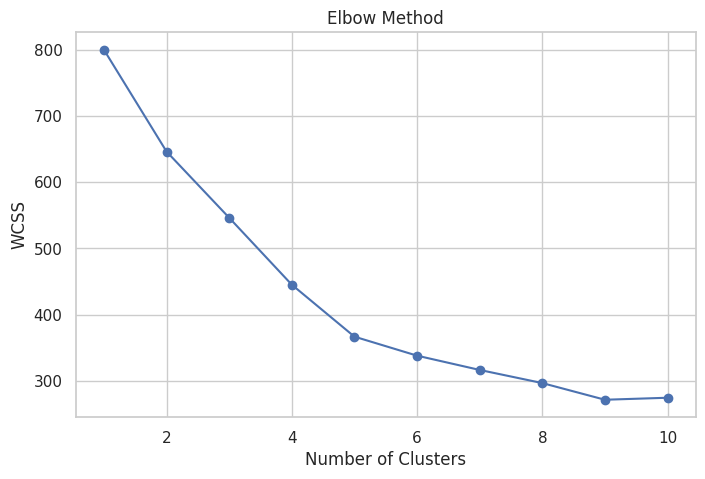

In [8]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [9]:
print("Silhouette Scores:")
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score:.3f}")

Silhouette Scores:
k=2, Silhouette Score=0.196
k=3, Silhouette Score=0.203
k=4, Silhouette Score=0.224
k=5, Silhouette Score=0.243
k=6, Silhouette Score=0.242
k=7, Silhouette Score=0.209
k=8, Silhouette Score=0.187
k=9, Silhouette Score=0.201
k=10, Silhouette Score=0.174


In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

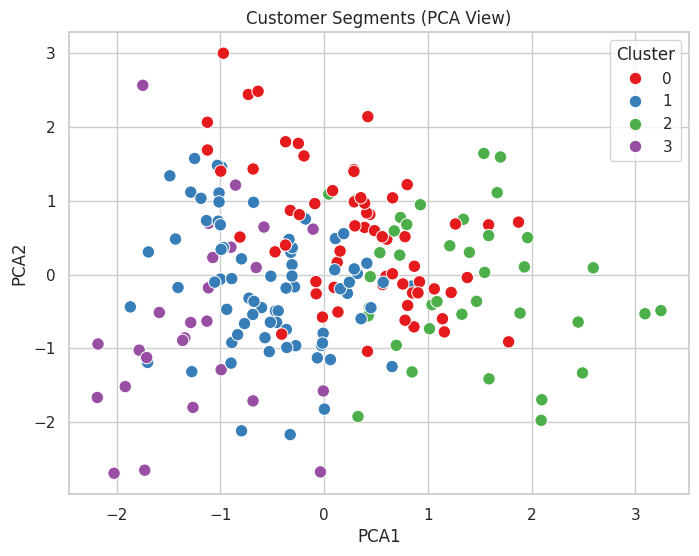

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster',
                data=df, palette='Set1', s=80)
plt.title("Customer Segments (PCA View)")
plt.show()

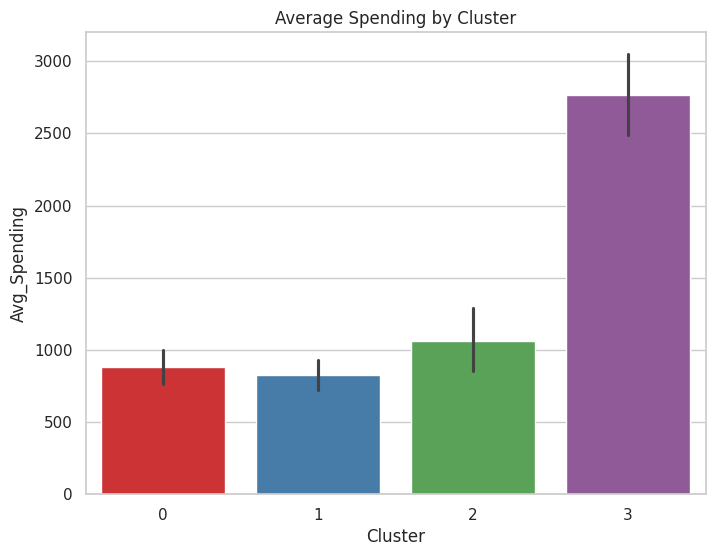

In [12]:
plt.figure(figsize=(8,6))
sns.barplot(x='Cluster',
            y='Avg_Spending',
            hue='Cluster',
            data=df,
            palette='Set1',
            legend=False)

plt.title("Average Spending by Cluster")
plt.show()

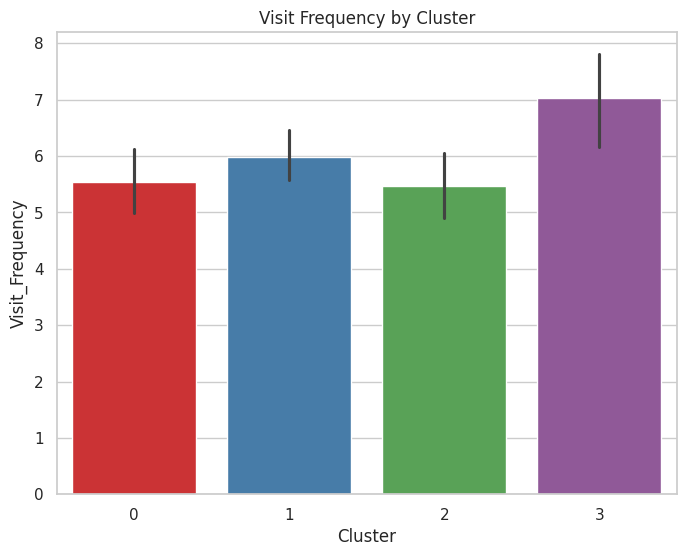

In [13]:
plt.figure(figsize=(8,6))
sns.barplot(x='Cluster',
            y='Visit_Frequency',
            hue='Cluster',
            data=df,
            palette='Set1',
            legend=False)

plt.title("Visit Frequency by Cluster")
plt.show()

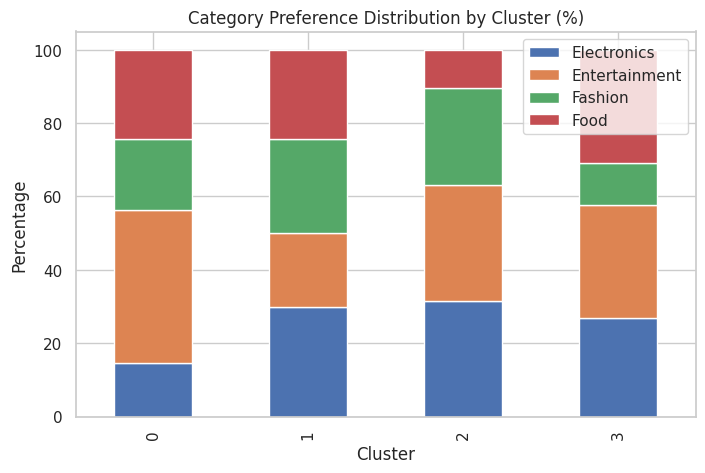

In [14]:
category_percent = pd.crosstab(
    df['Cluster'],
    df['Category_Preference'],
    normalize='index'
) * 100

category_percent.columns = le_category.classes_

category_percent.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Category Preference Distribution by Cluster (%)")
plt.ylabel("Percentage")
plt.show()

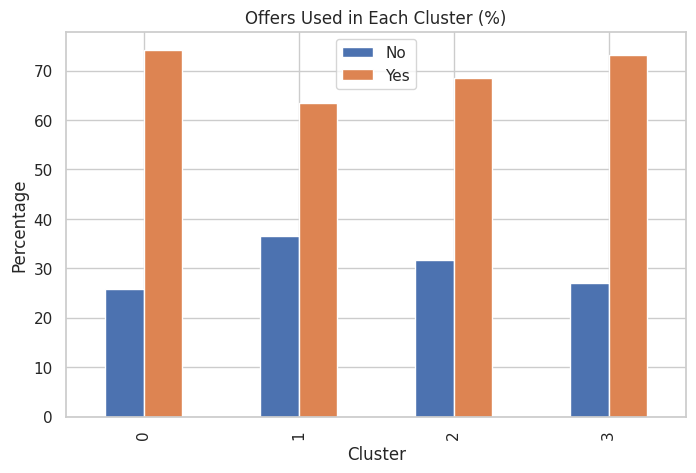

In [15]:
offer_analysis = pd.crosstab(
    df['Cluster'],
    df['Offers_Used'],
    normalize='index'
) * 100

offer_analysis.columns = le_offer.classes_

offer_analysis.plot(kind='bar', figsize=(8,5))
plt.title("Offers Used in Each Cluster (%)")
plt.ylabel("Percentage")
plt.show()

In [16]:
cluster_profile = df.groupby('Cluster')[
    ['Avg_Spending', 'Visit_Frequency',
     'Time_Spent_Minutes', 'Spending_Score']
].mean()

print("\nCluster Profile:\n")
print(cluster_profile)



Cluster Profile:

         Avg_Spending  Visit_Frequency  Time_Spent_Minutes  Spending_Score
Cluster                                                                   
0          882.403226         5.548387           50.693548       24.677419
1          824.459459         5.986486           50.243243       67.000000
2         1060.263158         5.473684          117.657895       41.342105
3         2766.461538         7.038462           46.076923       48.307692


In [17]:
segment_names = {
    0: "Deal-Oriented Customers",
    1: "Low Spending Customers",
    2: "Regular Customers",
    3: "Loyal High-Value Customers"
}

df['Segment'] = df['Cluster'].map(segment_names)

print(df[['Cluster', 'Segment']].head())

   Cluster                  Segment
0        2        Regular Customers
1        0  Deal-Oriented Customers
2        2        Regular Customers
3        1   Low Spending Customers
4        0  Deal-Oriented Customers


#STREAMLIT

In [18]:
!pip install streamlit pyngrok --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 53.2 MB/s eta 0:00:00


In [19]:
%%writefile app.py
# ======================================================
# MALL CUSTOMER INTELLIGENCE SYSTEM — UPDATED VERSION
# Multi-Category Proportional Offers + New Sidebar
# ======================================================
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from datetime import datetime
import plotly.graph_objects as go
import plotly.express as px
import os

st.set_page_config(page_title="Mall Intelligence", layout="wide")

DATA_PATH     = "Mall_Customer_Advanced_Dataset.csv"
CATEGORY_LIST = ["Fashion", "Entertainment", "Food", "Electronics"]

SEGMENT_NAMES = {0: "Deal-Oriented", 1: "Low Spending", 2: "Regular", 3: "High-Value"}

# All possible offers per category (pool to pick from based on spend tier)
CATEGORY_OFFERS_POOL = {
    "Fashion": [
        "👗 20% Off on all Fashion items",
        "👜 Free Accessories on orders above ₹8,000",
        "🛍️ Buy 2 Get 1 Free on selected Fashion brands",
        "💳 Extra 10% Cashback on Fashion purchases",
    ],
    "Entertainment": [
        "🎬 2-for-1 Movie Ticket",
        "🎮 1-Month Gaming Pass",
        "🎵 Free Concert Ticket on spend above ₹5,000",
        "🎠 15% Off on Entertainment activities",
    ],
    "Food": [
        "🍔 Free Dessert on next visit",
        "☕ 10% Cashback on Food",
        "🍕 Buy 1 Get 1 on selected Food outlets",
        "🥗 Free Meal Upgrade on spend above ₹2,000",
    ],
    "Electronics": [
        "📱 5% Discount on Electronics",
        "🎧 Free Headphones on purchase above ₹16,000",
        "🖥️ Extended Warranty (1 Year Free) on Electronics",
        "⚡ ₹1,000 Off on Electronics above ₹20,000",
    ],
}

SEGMENT_COLORS = {
    "Deal-Oriented": "#f59e0b",
    "Low Spending":  "#6b7280",
    "Regular":       "#3b82f6",
    "High-Value":    "#10b981",
}

CAT_COLORS = {
    "Fashion":       "#f59e0b",
    "Entertainment": "#8b5cf6",
    "Food":          "#ef4444",
    "Electronics":   "#3b82f6",
}

# -------------------------------------------------------
# MULTI-CATEGORY PROPORTIONAL OFFER ENGINE
# -------------------------------------------------------
def get_proportional_offers(cust):
    """
    Returns offers for a customer based on their spending in EACH category.
    - HIGH spend (>= 40% share)  -> 2 offers (PRIORITY)
    - MODERATE spend (15-39%)    -> 1 offer
    - LOW spend (1-14%)          -> 1 teaser offer
    - ZERO spend (0%)            -> no offers for that category
    """
    values = {}
    for cat in CATEGORY_LIST:
        col = f"{cat}_Spending"
        try:
            val = cust[col]
            values[cat] = float(val) if pd.notna(val) else 0.0
        except Exception:
            values[cat] = 0.0

    total = sum(values.values()) or 1.0
    shares = {cat: values[cat] / total * 100 for cat in CATEGORY_LIST}

    result = []
    # Sort by spend descending so highest spenders appear first
    sorted_cats = sorted(CATEGORY_LIST, key=lambda c: values[c], reverse=True)

    for cat in sorted_cats:
        share = shares[cat]
        pool  = CATEGORY_OFFERS_POOL[cat]
        if share == 0:
            continue  # no offers for categories not visited
        elif share >= 40:
            # HIGH: give 2 offers with a PRIORITY badge
            tier_label = "🔥 Priority"
            tier_color = CAT_COLORS[cat]
            result.append({
                "cat": cat, "share": share, "tier": tier_label,
                "color": tier_color, "offers": pool[:2]
            })
        elif share >= 15:
            # MODERATE: 1 offer
            tier_label = "⭐ Moderate"
            tier_color = CAT_COLORS[cat]
            result.append({
                "cat": cat, "share": share, "tier": tier_label,
                "color": tier_color, "offers": pool[:1]
            })
        else:
            # LOW: 1 teaser offer
            tier_label = "💡 Teaser"
            tier_color = "#475569"
            result.append({
                "cat": cat, "share": share, "tier": tier_label,
                "color": tier_color, "offers": pool[2:3]  # pick the 3rd offer as teaser
            })

    return result

# -------------------------------------------------------
# STYLES
# -------------------------------------------------------
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@700;800&family=DM+Sans:wght@400;500;600;700&display=swap');

html, body, [class*="css"], .stMarkdown, p, li, span, label, div {
    font-family: 'DM Sans', sans-serif !important;
    font-weight: 600 !important;
}
h1, h2, h3, h4, h5, h6 {
    font-family: 'Syne', sans-serif !important;
    font-weight: 800 !important;
    letter-spacing: -0.5px;
}
.stApp { background: #0a0d14; }
.stSidebar { display: none !important; }

/* ── HIDE SIDEBAR BUTTONS ── */
[data-testid="collapsedControl"],
[data-testid="stSidebarCollapsedControl"],
button[aria-label="Close sidebar"],
button[aria-label="Open sidebar"],
.stSidebarCollapseButton,
button[kind="header"],
section[data-testid="stSidebar"] button[kind="header"],
[data-testid="stSidebarNav"] {
    display: none !important;
}

/* ── TOP NAVBAR ── */
.top-navbar {
    display: flex;
    align-items: center;
    justify-content: space-between;
    background: #0d1117;
    border-bottom: 1px solid #1e2535;
    padding: 0 28px;
    height: 60px;
    position: sticky;
    top: 0;
    z-index: 999;
    margin-bottom: 24px;
}
.top-navbar-brand {
    font-family: 'Syne', sans-serif;
    font-weight: 800;
    font-size: 18px;
    color: #e2e8f0;
    display: flex;
    align-items: center;
    gap: 10px;
}
.top-navbar-brand-dot {
    width: 8px; height: 8px;
    border-radius: 50%;
    background: #3b82f6;
    display: inline-block;
}
.top-navbar-links {
    display: flex;
    align-items: center;
    gap: 4px;
}
.top-navbar-btn {
    font-family: 'DM Sans', sans-serif !important;
    font-weight: 700 !important;
    color: #94a3b8 !important;
    font-size: 14px !important;
    padding: 8px 16px !important;
    border-radius: 8px !important;
    cursor: pointer;
    transition: all 0.18s;
    background: transparent !important;
    border: 1px solid transparent !important;
    text-decoration: none;
}
.top-navbar-btn:hover {
    background: #1a2235 !important;
    color: #e2e8f0 !important;
    border-color: #243050 !important;
}
.top-navbar-btn.active {
    background: #1e3a5f !important;
    color: #60a5fa !important;
    border-color: #2563eb !important;
}
/* Streamlit radio used as top nav — hide label, horizontal layout */
.topnav-radio .stRadio > div[role="radiogroup"] {
    display: flex;
    flex-direction: row;
    gap: 4px;
}
.topnav-radio .stRadio > div[role="radiogroup"] > label {
    font-family: 'DM Sans', sans-serif !important;
    font-weight: 700 !important;
    color: #94a3b8 !important;
    font-size: 14px !important;
    padding: 8px 16px !important;
    border-radius: 8px !important;
    cursor: pointer;
    transition: all 0.18s;
    background: transparent !important;
    border: 1px solid transparent !important;
    display: flex;
    align-items: center;
    gap: 8px;
}
.topnav-radio .stRadio > div[role="radiogroup"] > label:hover {
    background: #1a2235 !important;
    color: #e2e8f0 !important;
    border-color: #243050 !important;
}
.topnav-radio .stRadio > div[role="radiogroup"] > label > div:first-child {
    display: none !important;
}

.card {
    padding: 24px 20px;
    border-radius: 16px;
    background: linear-gradient(135deg, #1a2340, #0f172a);
    border: 1px solid #1e2d4a;
    color: white;
    text-align: center;
    box-shadow: 0 8px 32px rgba(0,0,0,0.4);
}
.card h4 {
    margin: 0 0 8px 0;
    font-size: 12px;
    font-weight: 700 !important;
    color: #64748b;
    text-transform: uppercase;
    letter-spacing: 1.5px;
}
.card h2 {
    margin: 0;
    font-size: 32px;
    font-weight: 800 !important;
    color: #e2e8f0;
}
.card p { margin: 4px 0 0; font-size: 12px; color: #64748b; }

.panel {
    padding: 24px;
    border-radius: 16px;
    background: #111420;
    border: 1px solid #1e2535;
    color: white;
    box-shadow: 0 4px 20px rgba(0,0,0,0.3);
    margin-bottom: 14px;
}
.panel h3 { margin: 0 0 6px 0; font-size: 20px; color: #e2e8f0; }
.panel p  { margin: 8px 0; color: #94a3b8; font-size: 14px; }
.panel p b { color: #e2e8f0; font-weight: 700 !important; }

.alert-box {
    padding: 20px 24px;
    border-radius: 14px;
    background: linear-gradient(135deg, #1a1a2e, #16213e);
    border: 1px solid #e6b800;
    color: #fef3c7;
    margin-bottom: 18px;
    font-size: 15px;
    font-weight: 700 !important;
}
.alert-box .atitle {
    font-family: 'Syne', sans-serif !important;
    font-size: 17px;
    font-weight: 800 !important;
    color: #fde68a;
    margin-bottom: 6px;
}

.profit-banner {
    padding: 16px 24px; border-radius: 14px;
    background: linear-gradient(135deg, #064e3b, #065f46);
    border: 1px solid #10b981; color: #d1fae5;
    text-align: center; font-size: 17px; font-weight: 800 !important; margin-top: 12px;
}
.loss-banner {
    padding: 16px 24px; border-radius: 14px;
    background: linear-gradient(135deg, #4c0519, #7f1d1d);
    border: 1px solid #f43f5e; color: #ffe4e6;
    text-align: center; font-size: 17px; font-weight: 800 !important; margin-top: 12px;
}

.badge {
    display: inline-block; padding: 4px 14px;
    border-radius: 20px; font-size: 13px; font-weight: 700 !important; letter-spacing: 0.5px;
}

.success-card {
    padding: 20px 24px;
    border-radius: 14px;
    background: linear-gradient(135deg, #064e3b, #065f46);
    border: 1px solid #10b981;
    color: #d1fae5;
    margin-bottom: 18px;
}
.success-card .stitle {
    font-family: 'Syne', sans-serif !important;
    font-size: 18px;
    font-weight: 800 !important;
    color: #6ee7b7;
    margin-bottom: 10px;
}
.success-card p { margin: 5px 0; font-size: 14px; color: #a7f3d0; }
.success-card p b { color: #ecfdf5; font-weight: 700 !important; }

.delete-warning {
    padding: 20px 24px;
    border-radius: 14px;
    background: linear-gradient(135deg, #4c0519, #7f1d1d);
    border: 1px solid #f43f5e;
    color: #ffe4e6;
    margin-bottom: 18px;
    font-size: 15px;
    font-weight: 700 !important;
}
.delete-warning .dtitle {
    font-family: 'Syne', sans-serif !important;
    font-size: 17px;
    font-weight: 800 !important;
    color: #fca5a5;
    margin-bottom: 6px;
}

.stButton > button {
    font-family: 'DM Sans', sans-serif !important;
    font-weight: 700 !important; border-radius: 10px; padding: 10px 24px;
    background: linear-gradient(135deg, #1d4ed8, #2563eb);
    color: white; border: none; transition: all 0.2s;
}
.stButton > button:hover {
    background: linear-gradient(135deg, #2563eb, #3b82f6);
    transform: translateY(-1px); box-shadow: 0 6px 20px rgba(37,99,235,0.4);
}

.stSelectbox label, .stTextInput label, .stNumberInput label, .stCheckbox label {
    font-weight: 700 !important; color: #94a3b8 !important;
    font-size: 12px !important; text-transform: uppercase; letter-spacing: 1px;
}

.cat-row {
    display: flex;
    align-items: center;
    gap: 10px;
    margin: 8px 0;
}
.cat-label {
    font-family: 'DM Sans', sans-serif;
    font-weight: 700;
    color: #e2e8f0;
    font-size: 13px;
    min-width: 95px;
}
.cat-bar-wrap {
    flex: 1;
    background: #1e2535;
    border-radius: 6px;
    height: 8px;
    overflow: hidden;
}
.cat-bar-fill {
    height: 8px;
    border-radius: 6px;
    transition: width 0.4s ease;
}
.cat-value {
    font-family: 'DM Sans', sans-serif;
    font-weight: 700;
    color: #94a3b8;
    font-size: 13px;
    min-width: 85px;
    text-align: right;
}

/* ── OFFER CARD STYLES ── */
.offer-section-title {
    font-family: 'Syne', sans-serif;
    font-size: 16px;
    font-weight: 800;
    color: #e2e8f0;
    margin: 16px 0 10px;
}
.offer-group {
    border-radius: 12px;
    border: 1px solid #1e2535;
    background: #0f1420;
    padding: 14px 16px;
    margin-bottom: 10px;
}
.offer-group-header {
    display: flex;
    align-items: center;
    justify-content: space-between;
    margin-bottom: 8px;
}
.offer-cat-name {
    font-family: 'Syne', sans-serif;
    font-size: 14px;
    font-weight: 800;
    color: #e2e8f0;
}
.offer-tier-badge {
    font-size: 11px;
    font-weight: 700;
    padding: 3px 10px;
    border-radius: 20px;
}
.offer-share-bar-wrap {
    background: #1e2535;
    border-radius: 4px;
    height: 4px;
    margin-bottom: 10px;
    overflow: hidden;
}
.offer-share-bar-fill {
    height: 4px;
    border-radius: 4px;
}
.offer-item {
    font-family: 'DM Sans', sans-serif;
    font-size: 13px;
    font-weight: 600;
    color: #cbd5e1;
    padding: 5px 0;
    border-bottom: 1px solid #1e2535;
}
.offer-item:last-child {
    border-bottom: none;
}
</style>
""", unsafe_allow_html=True)

# -------------------------------------------------------
# SESSION STATE
# -------------------------------------------------------
for key, val in [
    ("logged_in", False),
    ("page", "Dashboard"),
    ("selected_customer_id", None),
    ("name_conflict", None),
    ("visit_success", None),
    ("confirm_delete_id", None),
]:
    if key not in st.session_state:
        st.session_state[key] = val

# -------------------------------------------------------
# LOGIN
# -------------------------------------------------------
def login():
    st.title("🔐 Admin Login")
    u = st.text_input("Username")
    p = st.text_input("Password", type="password")
    if st.button("Login"):
        if u == "admin" and p == "admin123":
            st.session_state.logged_in = True
            st.rerun()
        else:
            st.error("Invalid credentials")

if not st.session_state.logged_in:
    login()
    st.stop()

# -------------------------------------------------------
# DATA LOADING & PROCESSING
# -------------------------------------------------------
def load_data():
    if not os.path.exists(DATA_PATH):
        return pd.DataFrame()
    df = pd.read_csv(DATA_PATH)
    if df.empty:
        return df
    df["Customer_Name"] = df.get("Customer_Name", "").astype(str).str.lower().str.strip()
    df["Email"]         = df.get("Email", "").astype(str).str.lower().str.strip()
    for col in ["Customer_ID", "Avg_Spending", "Visit_Frequency", "Category_Preference"]:
        if col not in df.columns:
            df[col] = 0

    if "Offers_Used" not in df.columns:
        df["Offers_Used"] = "No"
    df["Offers_Used"] = df["Offers_Used"].astype(str).str.strip()
    df["Visit_Frequency"] = pd.to_numeric(df["Visit_Frequency"], errors="coerce").fillna(0).astype(int)
    df["Avg_Spending"]    = pd.to_numeric(df["Avg_Spending"],    errors="coerce").fillna(0.0)

    for cat in CATEGORY_LIST:
        c = f"{cat}_Spending"
        if c not in df.columns:
            df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    mask = (df[[f"{cat}_Spending" for cat in CATEGORY_LIST]].sum(axis=1) == 0) & (df["Avg_Spending"] > 0)
    for idx in df[mask].index:
        pref = str(df.at[idx, "Category_Preference"]).strip()
        spend = float(df.at[idx, "Avg_Spending"])
        visits = max(int(df.at[idx, "Visit_Frequency"]), 1)
        total = spend * visits
        for cat in CATEGORY_LIST:
            if cat == pref:
                df.at[idx, f"{cat}_Spending"] = round(total * 0.60, 2)
            else:
                df.at[idx, f"{cat}_Spending"] = round(total * 0.40 / (len(CATEGORY_LIST) - 1), 2)

    return df


def compute(df):
    if df.empty:
        return df
    max_spend = df["Avg_Spending"].max() or 1
    max_visit = df["Visit_Frequency"].max() or 1
    df["Score"] = ((df["Avg_Spending"] / max_spend) * 0.6 +
                   (df["Visit_Frequency"] / max_visit) * 0.4) * 100
    df["Score"] = df["Score"].clip(1, 100).astype(int)
    le = LabelEncoder()
    cat_col = df["Category_Preference"].astype(str).str.strip()
    cat_col = cat_col.apply(lambda x: x if x in CATEGORY_LIST else CATEGORY_LIST[0])
    df["Cat"] = le.fit_transform(cat_col)
    X = StandardScaler().fit_transform(df[["Avg_Spending", "Visit_Frequency", "Score", "Cat"]])
    model = KMeans(n_clusters=4, random_state=42, n_init=10)
    df["Segment"] = model.fit_predict(X)
    df["Segment"] = df["Segment"].map(SEGMENT_NAMES)
    return df


def refresh():
    return compute(load_data())

df = refresh()


def update_preferences_and_save(raw):
    for i in raw.index:
        spend = {cat: float(raw.at[i, f"{cat}_Spending"]) for cat in CATEGORY_LIST}
        total = sum(spend.values())
        if total > 0:
            raw.at[i, "Category_Preference"] = max(spend, key=spend.get)
        visits = max(int(raw.at[i, "Visit_Frequency"]), 1)
        raw.at[i, "Avg_Spending"] = total / visits
    raw.to_csv(DATA_PATH, index=False)


# -------------------------------------------------------
# SCORE GAUGE
# -------------------------------------------------------
def render_score_gauge(score: int):
    score = max(0, min(100, score))
    if score <= 33:
        bar_color = "#ef4444"
        zone      = "Low Spender"
    elif score <= 66:
        bar_color = "#f59e0b"
        zone      = "Medium Spender"
    else:
        bar_color = "#10b981"
        zone      = "High Spender"

    fig = go.Figure(go.Indicator(
        mode  = "gauge+number",
        value = score,
        title = {
            "text": f"<b>Spending Score</b><br><span style='font-size:12px;color:{bar_color}'>{zone}</span>",
            "font": {"size": 14, "color": "#94a3b8", "family": "DM Sans"}
        },
        number = {"font": {"size": 40, "color": "white", "family": "Syne"}, "suffix": ""},
        gauge  = {
            "axis": {
                "range"    : [0, 100],
                "tickwidth": 1,
                "tickcolor": "#475569",
                "tickfont" : {"color": "#475569", "size": 10},
                "nticks"   : 6,
            },
            "bar"        : {"color": bar_color, "thickness": 0.3},
            "bgcolor"    : "rgba(0,0,0,0)",
            "borderwidth": 0,
            "steps"      : [
                {"range": [0,  33], "color": "#1e1a20"},
                {"range": [33, 66], "color": "#1e1e18"},
                {"range": [66,100], "color": "#0f201a"},
            ],
            "threshold"  : {
                "line"     : {"color": bar_color, "width": 4},
                "thickness": 0.8,
                "value"    : score,
            },
        },
    ))
    fig.update_layout(
        height        = 230,
        margin        = dict(t=40, b=10, l=10, r=10),
        paper_bgcolor = "rgba(0,0,0,0)",
        plot_bgcolor  = "rgba(0,0,0,0)",
        font          = dict(family="DM Sans", color="white"),
    )
    st.plotly_chart(fig, use_container_width=True, config={"displayModeBar": False})


# -------------------------------------------------------
# CATEGORY BREAKDOWN
# -------------------------------------------------------
def render_cat_breakdown(cust):
    color_map = {
        "Fashion":       "#f59e0b",
        "Entertainment": "#8b5cf6",
        "Food":          "#ef4444",
        "Electronics":   "#3b82f6",
    }

    values = {}
    for cat in CATEGORY_LIST:
        col = f"{cat}_Spending"
        try:
            val = cust[col]
            values[cat] = float(val) if pd.notna(val) else 0.0
        except Exception:
            values[cat] = 0.0

    total = sum(values.values()) or 1.0

    st.markdown("##### 📊 Category Breakdown")

    rows_html = ""
    for cat in CATEGORY_LIST:
        val  = values[cat]
        pct  = round(val / total * 100, 1) if total > 0 else 0
        clr  = color_map[cat]
        rows_html += f"""
        <div class="cat-row">
          <span class="cat-label">{cat}</span>
          <div class="cat-bar-wrap">
            <div class="cat-bar-fill" style="width:{pct}%;background:{clr};"></div>
          </div>
          <span class="cat-value">₹{val:,.0f} &nbsp;<span style="color:#475569;font-size:11px;">({pct}%)</span></span>
        </div>"""

    st.markdown(rows_html, unsafe_allow_html=True)


# -------------------------------------------------------
# RENDER PERSONALISED OFFERS (MULTI-CATEGORY PROPORTIONAL)
# -------------------------------------------------------
def render_personalised_offers(cust):
    """Renders proportional multi-category offers based on actual spend split."""
    offer_groups = get_proportional_offers(cust)

    if not offer_groups:
        st.info("No category spending data found for this customer.")
        return

    st.markdown("<div class='offer-section-title'>🎁 Personalised Offers</div>", unsafe_allow_html=True)
    st.caption("Offers are tailored to your spending across all categories — more spend = more offers!")

    for group in offer_groups:
        cat   = group["cat"]
        share = group["share"]
        tier  = group["tier"]
        color = group["color"]
        offers = group["offers"]

        offers_html = "".join(
            f"<div class='offer-item'>{o}</div>" for o in offers
        )

        st.markdown(f"""
        <div class="offer-group" style="border-color:{color}33;">
          <div class="offer-group-header">
            <span class="offer-cat-name" style="color:{color};">{cat}</span>
            <span class="offer-tier-badge" style="background:{color}22;color:{color};border:1px solid {color}44;">{tier} — {share:.1f}%</span>
          </div>
          <div class="offer-share-bar-wrap">
            <div class="offer-share-bar-fill" style="width:{share}%;background:{color};"></div>
          </div>
          {offers_html}
        </div>""", unsafe_allow_html=True)


# -------------------------------------------------------
# CUSTOMER CARD
# -------------------------------------------------------
def render_customer_card(cust):
    seg_color = SEGMENT_COLORS.get(str(cust["Segment"]), "#6b7280")
    score     = int(cust["Score"])
    cust_id   = int(cust["Customer_ID"])
    last_date = str(cust.get("Last_Purchase_Date", "—"))
    join_date = str(cust.get("Join_Date", "—"))

    col_info, col_right = st.columns([3, 2])

    with col_info:
        st.markdown(f"""
        <div class="panel">
          <h3 style="margin-bottom:4px">{cust['Customer_Name'].title()}</h3>
          <p style="color:#475569;font-size:12px;margin-bottom:14px">
            Customer ID : <b style="color:#7dd3fc">#{cust_id}</b>
          </p>
          <p><b>📧 Email :</b> {cust.get('Email','—')}</p>
          <p><b>📅 Joined :</b> {join_date}</p>
          <p><b>🕐 Last Visit :</b> {last_date}</p>
          <p><b>🔁 Total Visits :</b> {int(cust['Visit_Frequency'])}</p>
          <p><b>💵 Avg Spend / Visit :</b> ₹{float(cust['Avg_Spending']):,.0f}</p>
          <p><b>🏷️ Preferred Category :</b> {cust['Category_Preference']}</p>
          <p><b>🎯 Segment :</b>
            <span class="badge"
              style="background:{seg_color}22;color:{seg_color};border:1px solid {seg_color}">
              {cust['Segment']}
            </span>
          </p>
          <p><b>🎟️ Offers Used :</b>
            <span class="badge" style="background:{'#064e3b' if str(cust.get('Offers_Used','No')).strip() == 'Yes' else '#4c0519'};color:{'#6ee7b7' if str(cust.get('Offers_Used','No')).strip() == 'Yes' else '#fca5a5'};border:1px solid {'#10b981' if str(cust.get('Offers_Used','No')).strip() == 'Yes' else '#f43f5e'}">
              {'✅ Yes' if str(cust.get('Offers_Used','No')).strip() == 'Yes' else '❌ No'}
            </span>
          </p>
        </div>""", unsafe_allow_html=True)

        # ── PROPORTIONAL MULTI-CATEGORY OFFERS ──
        render_personalised_offers(cust)

        # ── DEAL-ORIENTED OFFER USAGE ALERT ──
        if str(cust.get("Segment", "")) == "Deal-Oriented":
            used = str(cust.get("Offers_Used", "No")).strip()
            if used == "Yes":
                st.markdown("""
                <div class="profit-banner" style="margin-top:10px;">
                  🎉 Deal-Oriented Customer — <b>Offer was USED</b> in last visit!
                </div>""", unsafe_allow_html=True)
            else:
                st.markdown("""
                <div class="alert-box" style="margin-top:10px;">
                  <div class="atitle">⚠️ Deal-Oriented — No Offer Used</div>
                  This customer responds well to deals but <b>did not use any offer</b> in their last visit. Consider sending a targeted promotion!
                </div>""", unsafe_allow_html=True)

    with col_right:
        render_score_gauge(score)
        st.divider()
        render_cat_breakdown(cust)


# -------------------------------------------------------
# SESSION INITIALIZATION
# -------------------------------------------------------
if "page" not in st.session_state:
    st.session_state.page = "Dashboard"

if "logged_in" not in st.session_state:
    st.session_state.logged_in = True


# -------------------------------------------------------
# TOP NAVIGATION BAR
# -------------------------------------------------------
NAV_OPTIONS = ["📊  Dashboard", "➕  Add Visit", "📈  Graph Analytics"]

NAV_LABEL_TO_KEY = {
    "📊  Dashboard":       "Dashboard",
    "➕  Add Visit":       "Add Visit",
    "📈  Graph Analytics": "Graph Analytics",
}

NAV_KEY_TO_LABEL = {v: k for k, v in NAV_LABEL_TO_KEY.items()}

current_page  = st.session_state.get("page", "Dashboard")
current_label = NAV_KEY_TO_LABEL.get(current_page, "📊  Dashboard")

# Render top navbar brand + radio in columns
nav_col1, nav_col2, nav_col3 = st.columns([2, 5, 1])

with nav_col1:
    st.markdown("""
    <div class="top-navbar-brand">
        <span class="top-navbar-brand-dot"></span> Mall Intelligence
    </div>
    """, unsafe_allow_html=True)

with nav_col2:
    st.markdown('<div class="topnav-radio">', unsafe_allow_html=True)
    selected_label = st.radio(
        label="Pages",
        options=NAV_OPTIONS,
        index=NAV_OPTIONS.index(current_label),
        label_visibility="collapsed",
        horizontal=True,
        key="topnav_radio",
    )
    st.markdown('</div>', unsafe_allow_html=True)

with nav_col3:
    if st.button("🚪 Logout", use_container_width=True):
        st.session_state.logged_in = False
        st.rerun()

new_page = NAV_LABEL_TO_KEY[selected_label]
if new_page != st.session_state.page:
    st.session_state.page = new_page
    st.rerun()

st.markdown('<hr style="border:none;border-top:1px solid #1e2535;margin:0 0 20px 0;">', unsafe_allow_html=True)


# -------------------------------------------------------
# CURRENT PAGE VALUE
# -------------------------------------------------------
page = st.session_state.page

# =======================================================
# DASHBOARD
# =======================================================
if page == "Dashboard":

    st.title("📊 Executive Dashboard")

    if df.empty:
        st.warning("No data available.")
        st.stop()

    total_customers  = len(df)
    high_value_count = len(df[df["Segment"] == "High-Value"])
    top_segment      = df["Segment"].mode()[0]

    c1, c2, c3 = st.columns(3)
    c1.markdown(f"<div class='card'><h4>Total Customers</h4><h2>{total_customers}</h2></div>",       unsafe_allow_html=True)
    c2.markdown(f"<div class='card'><h4>High-Value Customers</h4><h2>{high_value_count}</h2></div>", unsafe_allow_html=True)
    c3.markdown(f"<div class='card'><h4>Top Segment</h4><h2>{top_segment}</h2></div>",               unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    most_loyal        = df.loc[df["Visit_Frequency"].idxmax(), "Customer_Name"].title()
    most_loyal_visits = int(df["Visit_Frequency"].max())
    top_category      = df["Category_Preference"].mode()[0]

    new_this_month = 0
    if "Join_Date" in df.columns:
        df["Join_Date_dt"] = pd.to_datetime(df["Join_Date"], errors="coerce")
        this_month         = datetime.now().replace(day=1)
        new_this_month     = len(df[df["Join_Date_dt"] >= this_month])

    d1, d2 = st.columns(2)
    d1.markdown(f"""
    <div class="card">
      <h4>Most Loyal Customer</h4>
      <h2 style="font-size:22px">{most_loyal}</h2>
      <p>{most_loyal_visits} visits</p>
    </div>""", unsafe_allow_html=True)

    d2.markdown(f"""
    <div class="card">
      <h4>New Customers This Month</h4>
      <h2>{new_this_month}</h2>
      <p>Top Category: {top_category}</p>
    </div>""", unsafe_allow_html=True)

    st.divider()

    st.subheader("📊 Category Breakdown — All Customers")

    all_cat_values = {}
    for cat in CATEGORY_LIST:
        col = f"{cat}_Spending"
        all_cat_values[cat] = float(df[col].sum()) if col in df.columns else 0.0

    total_all = sum(all_cat_values.values()) or 1.0
    color_map_cat = {
        "Fashion":       "#f59e0b",
        "Entertainment": "#8b5cf6",
        "Food":          "#ef4444",
        "Electronics":   "#3b82f6",
    }

    rows_html = ""
    for cat in CATEGORY_LIST:
        val  = all_cat_values[cat]
        pct  = round(val / total_all * 100, 1)
        clr  = color_map_cat[cat]
        rows_html += f"""
        <div class="cat-row">
          <span class="cat-label">{cat}</span>
          <div class="cat-bar-wrap">
            <div class="cat-bar-fill" style="width:{pct}%;background:{clr};"></div>
          </div>
          <span class="cat-value">₹{val:,.0f} &nbsp;<span style="color:#475569;font-size:11px;">({pct}%)</span></span>
        </div>"""
    st.markdown(rows_html, unsafe_allow_html=True)

    st.divider()

    st.subheader("🔎 Customer Details")

    df["_label"] = "#" + df["Customer_ID"].astype(str) + "  —  " + df["Customer_Name"].str.title()
    label_to_id  = dict(zip(df["_label"], df["Customer_ID"]))
    all_labels   = df["_label"].tolist()

    default_idx = 0
    if st.session_state.selected_customer_id:
        match = df[df["Customer_ID"] == st.session_state.selected_customer_id]["_label"]
        if not match.empty and match.values[0] in all_labels:
            default_idx = all_labels.index(match.values[0])

    chosen_label = st.selectbox("Select a customer", all_labels, index=default_idx, key="customer_select")
    cid_dash     = label_to_id[chosen_label]
    st.session_state.selected_customer_id = cid_dash

    cust = df[df["Customer_ID"] == cid_dash].iloc[0]
    render_customer_card(cust)

    st.divider()

    st.subheader("🗑️ Delete Customer")

    if st.session_state.confirm_delete_id is not None:
        del_id   = st.session_state.confirm_delete_id
        raw_temp = load_data()
        del_row  = raw_temp[raw_temp["Customer_ID"] == del_id]

        if not del_row.empty:
            del_name = del_row.iloc[0]["Customer_Name"].title()
            st.markdown(f"""
            <div class="delete-warning">
              <div class="dtitle">⚠️ Confirm Deletion</div>
              You are about to permanently delete <b>{del_name}</b> (ID: #{del_id}).
              This action cannot be undone.
            </div>""", unsafe_allow_html=True)

            col_yes, col_no = st.columns(2)
            with col_yes:
                if st.button("✅ Yes, Delete Customer", use_container_width=True, key="confirm_delete_yes"):
                    raw_temp = raw_temp[raw_temp["Customer_ID"] != del_id]
                    raw_temp.to_csv(DATA_PATH, index=False)
                    st.session_state.confirm_delete_id    = None
                    st.session_state.selected_customer_id = None
                    st.success(f"✅ Customer '{del_name}' (ID: #{del_id}) has been deleted successfully.")
                    st.rerun()
            with col_no:
                if st.button("❌ Cancel", use_container_width=True, key="confirm_delete_no"):
                    st.session_state.confirm_delete_id = None
                    st.rerun()
        else:
            st.session_state.confirm_delete_id = None
            st.rerun()
    else:
        cust_name_display = cust["Customer_Name"].title()
        st.write(f"Selected customer: **{cust_name_display}** (ID: #{int(cust['Customer_ID'])})")
        if st.button(f"🗑️ Delete {cust_name_display}", type="primary", key="delete_button"):
            st.session_state.confirm_delete_id = int(cust["Customer_ID"])
            st.rerun()


# =======================================================
# ADD VISIT
# =======================================================
elif page == "Add Visit":

    st.title("➕ Add Customer Visit")

    if st.session_state.visit_success is not None:
        info = st.session_state.visit_success
        if info["action"] == "added":
            st.markdown(f"""
            <div class="success-card">
              <div class="stitle">✅ Customer Added Successfully!</div>
              <p><b>Customer ID :</b> #{info['customer_id']}</p>
              <p><b>Customer Name :</b> {info['customer_name'].title()}</p>
              <p><b>Added Date :</b> {info['date']}</p>
            </div>""", unsafe_allow_html=True)
        elif info["action"] == "updated":
            st.markdown(f"""
            <div class="success-card">
              <div class="stitle">✅ Customer Updated Successfully!</div>
              <p><b>Customer ID :</b> #{info['customer_id']}</p>
              <p><b>Customer Name :</b> {info['customer_name'].title()}</p>
              <p><b>Updated Date :</b> {info['date']}</p>
            </div>""", unsafe_allow_html=True)

        if st.button("➕ Add Another Visit", key="add_another_visit"):
            st.session_state.visit_success = None
            st.rerun()
        st.stop()

    if st.session_state.name_conflict is not None:
        pending = st.session_state.name_conflict

        st.markdown(f"""
        <div class="alert-box">
          <div class="atitle">⚠️ Same Name Detected</div>
          A customer named <b>{pending['name'].title()}</b> already exists.
          Is this the same person visiting again, or a brand-new customer?
        </div>""", unsafe_allow_html=True)

        col1, col2 = st.columns(2)

        with col1:
            if st.button("✅ Existing Customer — Update Data", use_container_width=True, key="existing_customer_btn"):
                raw    = load_data()
                idx    = raw[raw["Customer_Name"] == pending["name"]].index[0]
                visits = int(raw.at[idx, "Visit_Frequency"]) + 1
                raw.at[idx, "Visit_Frequency"]    = visits
                raw.at[idx, "Last_Purchase_Date"] = datetime.now().strftime("%Y-%m-%d")
                raw.at[idx, "Offers_Used"]        = pending.get("offers_used", "No")
                for cat in CATEGORY_LIST:
                    raw.at[idx, f"{cat}_Spending"] += pending["cat_spend"][cat]
                update_preferences_and_save(raw)
                st.session_state.visit_success = {
                    "action"       : "updated",
                    "customer_id"  : int(raw.at[idx, "Customer_ID"]),
                    "customer_name": raw.at[idx, "Customer_Name"],
                    "date"         : datetime.now().strftime("%Y-%m-%d"),
                }
                st.session_state.name_conflict = None
                st.rerun()

        with col2:
            if st.button("🆕 New Customer — Add as New", use_container_width=True, key="new_customer_btn"):
                raw    = load_data()
                new_id = int(raw["Customer_ID"].max() + 1) if not raw.empty else 1
                total  = sum(pending["cat_spend"].values())
                row    = {
                    "Customer_ID": new_id, "Customer_Name": pending["name"],
                    "Email": pending["email"], "Avg_Spending": total,
                    "Visit_Frequency": 1, "Join_Date": datetime.now().strftime("%Y-%m-%d"),
                    "Last_Purchase_Date": datetime.now().strftime("%Y-%m-%d"),
                    "Offers_Used": pending.get("offers_used", "No")
                }
                for cat in CATEGORY_LIST:
                    row[f"{cat}_Spending"] = pending["cat_spend"][cat]
                raw = pd.concat([raw, pd.DataFrame([row])], ignore_index=True)
                update_preferences_and_save(raw)
                st.session_state.visit_success = {
                    "action"       : "added",
                    "customer_id"  : new_id,
                    "customer_name": pending["name"],
                    "date"         : datetime.now().strftime("%Y-%m-%d"),
                }
                st.session_state.name_conflict = None
                st.rerun()

        if st.button("← Cancel", key="conflict_cancel"):
            st.session_state.name_conflict = None
            st.rerun()

        st.stop()

    MIN_SPEND = 200
    MAX_SPEND = 1500000

    st.info("ℹ️ Minimum spend per category is ₹200. Enter 0 to skip a category.")

    with st.form("visit_form"):
        name  = st.text_input("Customer Name")
        email = st.text_input("Email")

        total     = 0
        cat_spend = {}
        cols = st.columns(len(CATEGORY_LIST))
        for i, cat in enumerate(CATEGORY_LIST):
            with cols[i]:
                val = st.number_input(
                    f"{cat} (₹)",
                    min_value=0,
                    max_value=MAX_SPEND,
                    value=0,
                    step=100,
                    help=f"Enter 0 to skip, or ₹{MIN_SPEND}+ if visited",
                    key=f"spend_{cat}"
                )
                cat_spend[cat] = val
                total += val

        st.markdown("---")
        offers_used_input = st.radio(
            "🎟️ Did the customer use any offer during this visit?",
            options=["No", "Yes"],
            index=0,
            horizontal=True,
            key="offers_used_radio"
        )

        submit = st.form_submit_button("💾 Save Visit")

        if submit:
            name_clean = name.lower().strip()

            if not name_clean:
                st.error("Please enter a valid customer name.")
                st.stop()

            if total == 0:
                st.error("Total spending cannot be zero. Please enter at least one category spend.")
                st.stop()

            invalid_cats = [cat for cat in CATEGORY_LIST if 0 < cat_spend[cat] < MIN_SPEND]
            if invalid_cats:
                st.error(
                    f"Minimum spend per category is ₹{MIN_SPEND:,}. "
                    f"Please fix: {', '.join(invalid_cats)}. Enter 0 to skip a category."
                )
                st.stop()

            email_clean = email.lower().strip()
            raw         = load_data()

            if email_clean:
                em = raw[raw["Email"] == email_clean]
                if not em.empty:
                    idx    = em.index[0]
                    visits = int(raw.at[idx, "Visit_Frequency"]) + 1
                    raw.at[idx, "Visit_Frequency"]    = visits
                    raw.at[idx, "Last_Purchase_Date"] = datetime.now().strftime("%Y-%m-%d")
                    raw.at[idx, "Offers_Used"]        = offers_used_input
                    for cat in CATEGORY_LIST:
                        raw.at[idx, f"{cat}_Spending"] += cat_spend[cat]
                    update_preferences_and_save(raw)
                    st.session_state.visit_success = {
                        "action"       : "updated",
                        "customer_id"  : int(raw.at[idx, "Customer_ID"]),
                        "customer_name": raw.at[idx, "Customer_Name"],
                        "date"         : datetime.now().strftime("%Y-%m-%d"),
                    }
                    st.rerun()

            nm = raw[raw["Customer_Name"] == name_clean]
            if not nm.empty:
                st.session_state.name_conflict = {
                    "name": name_clean, "email": email_clean,
                    "total": total, "cat_spend": cat_spend,
                    "offers_used": offers_used_input
                }
                st.rerun()

            new_id = int(raw["Customer_ID"].max() + 1) if not raw.empty else 1
            row    = {
                "Customer_ID": new_id, "Customer_Name": name_clean,
                "Email": email_clean, "Avg_Spending": total,
                "Visit_Frequency": 1, "Join_Date": datetime.now().strftime("%Y-%m-%d"),
                "Last_Purchase_Date": datetime.now().strftime("%Y-%m-%d"),
                "Offers_Used": offers_used_input
            }
            for cat in CATEGORY_LIST:
                row[f"{cat}_Spending"] = cat_spend[cat]
            raw = pd.concat([raw, pd.DataFrame([row])], ignore_index=True)
            update_preferences_and_save(raw)
            st.session_state.visit_success = {
                "action"       : "added",
                "customer_id"  : new_id,
                "customer_name": name_clean,
                "date"         : datetime.now().strftime("%Y-%m-%d"),
            }
            st.rerun()


# =======================================================
# GRAPH ANALYTICS
# =======================================================
elif page == "Graph Analytics":

    st.title("📈 Graph Analytics")

    df = refresh()

    if df.empty:
        st.warning("No data available for analysis.")
        st.stop()

    st.subheader("👥 Customer Distribution by Segment")

    seg_counts         = df["Segment"].value_counts().reset_index()
    seg_counts.columns = ["Segment", "Count"]

    cp, cb = st.columns(2)

    with cp:
        fig_pie = px.pie(
            seg_counts, names="Segment", values="Count",
            color="Segment", color_discrete_map=SEGMENT_COLORS, hole=0.5
        )
        fig_pie.update_layout(
            paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
            font=dict(family="DM Sans", color="#e2e8f0", size=13),
            legend=dict(font=dict(size=13, color="#e2e8f0")),
            margin=dict(t=20, b=20)
        )
        fig_pie.update_traces(textfont_size=13, textfont_color="white")
        st.plotly_chart(fig_pie, use_container_width=True, config={"displayModeBar": False})

    with cb:
        fig_bar = px.bar(
            seg_counts, x="Segment", y="Count",
            color="Segment", color_discrete_map=SEGMENT_COLORS, text="Count"
        )
        fig_bar.update_layout(
            paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
            font=dict(family="DM Sans", color="#e2e8f0", size=13),
            xaxis=dict(showgrid=False, color="#64748b"),
            yaxis=dict(showgrid=True, gridcolor="#1e2535", color="#64748b"),
            showlegend=False, margin=dict(t=10, b=10)
        )
        fig_bar.update_traces(textposition="outside", textfont_size=13)
        st.plotly_chart(fig_bar, use_container_width=True, config={"displayModeBar": False})

    st.divider()

    st.subheader("🔍 Customer Behaviour Analysis")

    ca, cb2 = st.columns(2)

    with ca:
        q1_s  = df["Avg_Spending"].quantile(0.05)
        q99_s = df["Avg_Spending"].quantile(0.95)
        q1_v  = df["Visit_Frequency"].quantile(0.05)
        q99_v = df["Visit_Frequency"].quantile(0.95)
        sc_df = df[
            (df["Avg_Spending"]    >= q1_s)  & (df["Avg_Spending"]    <= q99_s) &
            (df["Visit_Frequency"] >= q1_v)  & (df["Visit_Frequency"] <= q99_v)
        ].copy()

        fig_sc = px.scatter(
            sc_df, x="Visit_Frequency", y="Avg_Spending",
            color="Segment", color_discrete_map=SEGMENT_COLORS,
            size="Score", hover_data=["Customer_Name", "Customer_ID"],
            labels={
                "Visit_Frequency": "Visit Frequency",
                "Avg_Spending": "Avg Spending (₹)"
            }
        )
        fig_sc.update_layout(
            paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
            font=dict(family="DM Sans", color="#e2e8f0", size=13),
            xaxis=dict(showgrid=True, gridcolor="#1e2535", color="#64748b"),
            yaxis=dict(
                showgrid=True, gridcolor="#1e2535", color="#64748b",
                tickprefix="₹", tickformat=","
            ),
            title_font=dict(family="Syne", size=16, color="#e2e8f0"),
            legend=dict(font=dict(size=12)),
            title_text="Spend vs Visits",
            hovermode="closest"
        )
        fig_sc.update_traces(
            hovertemplate="<b>%{customdata[0]}</b><br>ID: #%{customdata[1]}<br>"
                          "Visits: %{x}<br>Avg Spend: ₹%{y:,.0f}<extra></extra>"
        )
        st.plotly_chart(fig_sc, use_container_width=True, config={"displayModeBar": False})

    with cb2:
        cat_totals = {}
        for cat in CATEGORY_LIST:
            col = f"{cat}_Spending"
            cat_totals[cat] = float(df[col].sum()) if col in df.columns else 0.0

        cat_df  = pd.DataFrame(list(cat_totals.items()), columns=["Category", "Total_Spending"])
        cat_df  = cat_df[cat_df["Total_Spending"] > 0]

        fig_cat = px.bar(
            cat_df, x="Category", y="Total_Spending",
            color="Category",
            color_discrete_map=CAT_COLORS,
            text="Total_Spending",
            labels={"Total_Spending": "Total Spending (₹)"}
        )
        fig_cat.update_layout(
            paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
            font=dict(family="DM Sans", color="#e2e8f0", size=13),
            xaxis=dict(showgrid=False, color="#64748b"),
            yaxis=dict(
                showgrid=True, gridcolor="#1e2535", color="#64748b",
                tickprefix="₹", tickformat=","
            ),
            showlegend=False,
            title_font=dict(family="Syne", size=16, color="#e2e8f0"),
            title_text="Total Spending by Category",
            margin=dict(t=40)
        )
        fig_cat.update_traces(
            texttemplate="₹%{text:,.0f}",
            textposition="outside",
            textfont_size=12,
            hovertemplate="<b>%{x}</b><br>Total Spending: ₹%{y:,.0f}<extra></extra>"
        )
        st.plotly_chart(fig_cat, use_container_width=True, config={"displayModeBar": False})

    st.divider()

    st.subheader("💰 Spending History & Profit Trend")

    raw = df.copy()

    if "Last_Purchase_Date" in raw.columns:
        raw["Last_Purchase_Date"] = pd.to_datetime(raw["Last_Purchase_Date"], errors="coerce")

        raw["Week"] = raw["Last_Purchase_Date"].dt.to_period("W").apply(lambda r: r.start_time)

        trend_df = (
            raw.dropna(subset=["Last_Purchase_Date"])
               .groupby("Week")
               .agg(
                   Total_Spending=("Avg_Spending", "sum"),
                   Customers=("Customer_ID", "count")
               )
               .reset_index()
               .sort_values("Week")
        )

        if len(trend_df) > 1:
            avg_weekly_rev           = trend_df["Total_Spending"].mean()
            COST_PER_WEEK            = avg_weekly_rev * 0.45
            trend_df["Profit"]       = trend_df["Total_Spending"] - COST_PER_WEEK
            trend_df["Profit_Color"] = trend_df["Profit"].apply(
                lambda x: "#10b981" if x >= 0 else "#f43f5e"
            )

            fig_rev = go.Figure()

            fig_rev.add_trace(go.Scatter(
                x=trend_df["Week"],
                y=trend_df["Total_Spending"],
                mode="lines+markers",
                name="Weekly Revenue",
                line=dict(color="#3b82f6", width=2.5),
                marker=dict(size=7, color="#3b82f6"),
                hovertemplate="<b>%{x|%b %d, %Y}</b><br>Revenue: ₹%{y:,.0f}<extra></extra>"
            ))

            fig_rev.add_trace(go.Scatter(
                x=trend_df["Week"],
                y=[COST_PER_WEEK] * len(trend_df),
                mode="lines",
                name="Estimated Cost (45%)",
                line=dict(color="#f59e0b", width=2.5, dash="dot"),
                hovertemplate="Est. Cost: ₹%{y:,.0f}<extra></extra>"
            ))

            fig_rev.update_layout(
                paper_bgcolor="rgba(0,0,0,0)",
                plot_bgcolor="rgba(0,0,0,0)",
                font=dict(family="DM Sans", color="#e2e8f0", size=13),
                height=320,
                xaxis=dict(
                    title="Week",
                    showgrid=True,
                    gridcolor="#1e2535",
                    color="#94a3b8",
                    tickfont=dict(size=12, color="#94a3b8"),
                    tickangle=-30,
                    tickformat="%b %d",
                ),
                yaxis=dict(
                    title="Amount (₹)",
                    showgrid=True,
                    gridcolor="#1e2535",
                    color="#94a3b8",
                    tickprefix="₹",
                    tickformat=",.0f",
                    tickfont=dict(size=12, color="#94a3b8"),
                    rangemode="tozero",
                ),
                legend=dict(
                    orientation="h",
                    yanchor="bottom",
                    y=1.02,
                    xanchor="right",
                    x=1,
                    font=dict(size=13, color="#e2e8f0"),
                    bgcolor="rgba(0,0,0,0)"
                ),
                hovermode="x unified",
                margin=dict(t=50, b=50, l=80, r=20),
            )
            st.plotly_chart(fig_rev, use_container_width=True, config={"displayModeBar": False})

            fig_profit = go.Figure()

            fig_profit.add_trace(go.Bar(
                x=trend_df["Week"],
                y=trend_df["Profit"],
                name="Profit / Loss",
                marker=dict(
                    color=trend_df["Profit_Color"],
                    line=dict(width=0)
                ),
                opacity=0.85,
                hovertemplate="<b>%{x|%b %d, %Y}</b><br>Profit/Loss: ₹%{y:,.0f}<extra></extra>"
            ))

            fig_profit.add_hline(
                y=0,
                line_color="#64748b",
                line_width=1.5,
                line_dash="dash",
            )

            fig_profit.update_layout(
                paper_bgcolor="rgba(0,0,0,0)",
                plot_bgcolor="rgba(0,0,0,0)",
                font=dict(family="DM Sans", color="#e2e8f0", size=13),
                height=280,
                xaxis=dict(
                    title="Week",
                    showgrid=True,
                    gridcolor="#1e2535",
                    color="#94a3b8",
                    tickfont=dict(size=12, color="#94a3b8"),
                    tickangle=-30,
                    tickformat="%b %d",
                ),
                yaxis=dict(
                    title="Profit / Loss (₹)",
                    showgrid=True,
                    gridcolor="#1e2535",
                    color="#94a3b8",
                    tickprefix="₹",
                    tickformat=",.0f",
                    tickfont=dict(size=12, color="#94a3b8"),
                    zeroline=True,
                    zerolinecolor="#475569",
                    zerolinewidth=1,
                ),
                showlegend=True,
                legend=dict(
                    orientation="h",
                    yanchor="bottom",
                    y=1.02,
                    xanchor="right",
                    x=1,
                    font=dict(size=13, color="#e2e8f0"),
                    bgcolor="rgba(0,0,0,0)"
                ),
                hovermode="x unified",
                margin=dict(t=50, b=50, l=80, r=20),
                bargap=0.3,
            )
            st.plotly_chart(fig_profit, use_container_width=True, config={"displayModeBar": False})

            total_rev  = trend_df["Total_Spending"].sum()
            total_cost = COST_PER_WEEK * len(trend_df)
            net        = total_rev - total_cost

            if net >= 0:
                st.markdown(
                    f"<div class='profit-banner'>✅ Overall Profit: ₹{net:,.0f} — Mall is in the GREEN 🟢</div>",
                    unsafe_allow_html=True
                )
            else:
                st.markdown(
                    f"<div class='loss-banner'>❌ Net Loss: ₹{abs(net):,.0f} — Review cost structure 🔴</div>",
                    unsafe_allow_html=True
                )

            st.divider()
            m1, m2, m3, m4 = st.columns(4)
            m1.markdown(f"<div class='card'><h4>Total Revenue</h4><h2>₹{total_rev:,.0f}</h2></div>",      unsafe_allow_html=True)
            m2.markdown(f"<div class='card'><h4>Total Cost (Est.)</h4><h2>₹{total_cost:,.0f}</h2></div>", unsafe_allow_html=True)
            m3.markdown(f"<div class='card'><h4>Net Profit</h4><h2>₹{net:,.0f}</h2></div>",               unsafe_allow_html=True)
            margin = (net / total_rev * 100) if total_rev else 0
            m4.markdown(f"<div class='card'><h4>Profit Margin</h4><h2>{margin:.1f}%</h2></div>",          unsafe_allow_html=True)
        else:
            st.info("Not enough purchase data for trend analysis. Add more visits first.")
    else:
        st.info("No purchase date data available. Add some visits first.")


Writing app.py


In [21]:
from pyngrok import ngrok
import os

# Kill previous sessions
ngrok.kill()

# TODO: Replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken
# You can get your authtoken from https://dashboard.ngrok.com/get-started/yyour-authtoken
ngrok.set_auth_token("3CS2HcHOl6UqXBhJ3WjcMPGdJ6R_3XxduWuCJmkW3jWQGvXNn")

# Run streamlit
!streamlit run app.py &>/dev/null&

# Create public link
public_url = ngrok.connect(8501)
print("✅ Your Streamlit App is Live at:")
print(public_url)

✅ Your Streamlit App is Live at:
NgrokTunnel: "https://grimace-energy-vivacious.ngrok-free.dev" -> "http://localhost:8501"
